<style>
.jp-Notebook,
.jp-NotebookPanel-notebook,
main {
    max-width: 1080px;
    margin-left: auto !important;
    margin-right: auto !important;
}

.jp-RenderedHTMLCommon p,
.text_cell_render p {
    text-align: justify;
    text-justify: inter-word;
    line-height: 1.65;
}

.jp-OutputArea-output img,
.jp-RenderedImage img,
.output_png img,
div.output_area img,
div.output_subarea img {
    display: block;
    max-width: 94%;
    height: auto;
    margin: 0.4rem auto 0.6rem !important;
}

.figure-caption {
    margin: 0.65rem auto 0.25rem !important;
    text-align: center !important;
    font-size: 1rem;
    line-height: 1.45 !important;
}

.figure-interpretation {
    max-width: 94%;
    margin: 0.35rem auto 1.75rem !important;
    text-align: justify !important;
    text-justify: inter-word;
    line-height: 1.65 !important;
}

.interpretation-label {
    font-style: italic;
    font-weight: 600;
}
</style>

# Itô's Formula: Reading the Correction Term

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 3015

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

BLUE = "#4C78A8"
ORANGE = "#F58518"
GREEN = "#54A24B"
PURPLE = "#8E6C8A"
GREY = "#6B7280"
LIGHT_GREY = "#D1D5DB"
INK = "#1F2937"


def brownian_paths(rng, path_count, interval_count, horizon=1.0):
    dt = horizon / interval_count
    increments = np.sqrt(dt) * rng.standard_normal((path_count, interval_count))
    paths = np.concatenate([np.zeros((path_count, 1)), np.cumsum(increments, axis=1)], axis=1)
    return increments, paths

## 1. Taylor's second-order term survives Brownian refinement

For $f\in C^2(\mathbb R)$, Itô's formula states

$$
f(B_t)-f(0)
=\int_0^t f'(B_s)\,dB_s
+\frac12\int_0^t f''(B_s)\,ds.
$$

On a partition, Taylor expansion gives

$$
f(B_{t_{i+1}})-f(B_{t_i})
=f'(B_{t_i})\Delta B_i
+\frac12 f''(B_{t_i})(\Delta B_i)^2
+r_i.
$$

The sum of first-order terms becomes the Itô integral. Because $\sum_i(\Delta B_i)^2\to t$, the second-order terms accumulate at order one and become the time integral. Higher-order remainders vanish under the regularity assumptions used in the theorem.

For $f(x)=e^x$, the endpoint difference is compared with first-order and second-order left-point sums over many Brownian paths.

 N      first-order RMSE      corrected RMSE
  8           1.019616           0.194867
 16           0.886574           0.080421
 32           0.838764           0.040259
 64           0.812024           0.020543
128           0.799590           0.009939
256           0.791202           0.004969


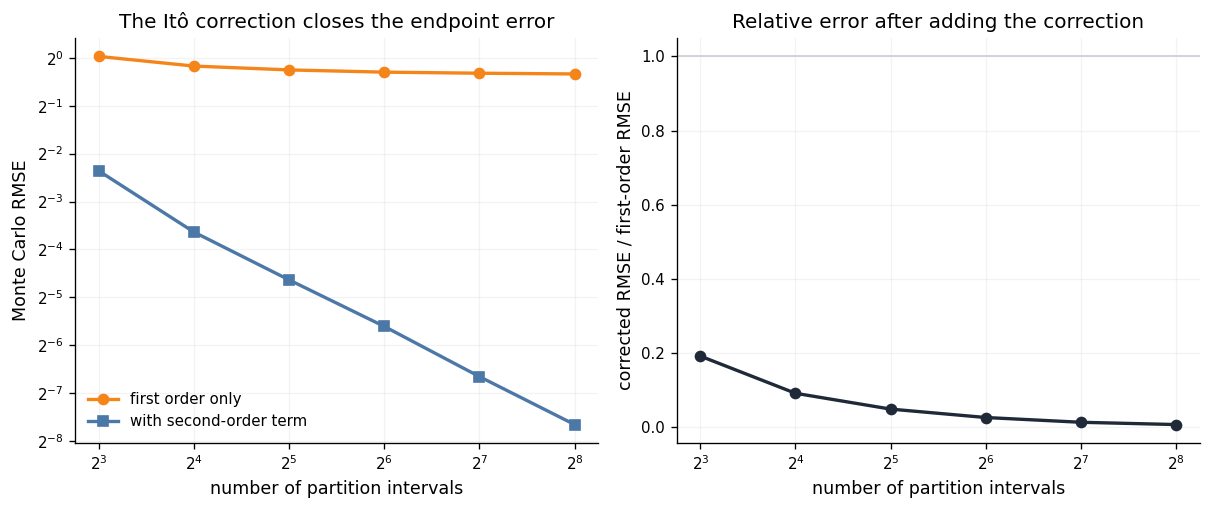

In [2]:
rng = np.random.default_rng(SEED + 20)
T = 1.0
n_paths = 14_000
fine_count = 256
dt_fine = T / fine_count
dB_fine, B_fine = brownian_paths(rng, n_paths, fine_count, T)
partition_counts = 2 ** np.arange(3, 9)
first_order_rmse = []
corrected_rmse = []

for count in partition_counts:
    block = fine_count // count
    increments = dB_fine.reshape(n_paths, count, block).sum(axis=2)
    left_values = B_fine[:, ::block][:, :-1]
    first_order = np.sum(np.exp(left_values) * increments, axis=1)
    second_order = first_order + 0.5 * np.sum(np.exp(left_values) * increments**2, axis=1)
    corrected = second_order
    endpoint = np.exp(B_fine[:, -1]) - 1.0
    first_order_rmse.append(np.sqrt(np.mean((first_order - endpoint) ** 2)))
    corrected_rmse.append(np.sqrt(np.mean((corrected - endpoint) ** 2)))

first_order_rmse = np.asarray(first_order_rmse)
corrected_rmse = np.asarray(corrected_rmse)
print(" N      first-order RMSE      corrected RMSE")
for count, first_error, corrected_error in zip(partition_counts, first_order_rmse, corrected_rmse):
    print(f"{count:>3d}          {first_error:>9.6f}          {corrected_error:>9.6f}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

axes[0].plot(partition_counts, first_order_rmse, marker="o", color=ORANGE, linewidth=2.0, label="first order only")
axes[0].plot(partition_counts, corrected_rmse, marker="s", color=BLUE, linewidth=2.0, label="with second-order term")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log", base=2)
axes[0].set_title("The Itô correction closes the endpoint error")
axes[0].set_xlabel("number of partition intervals")
axes[0].set_ylabel("Monte Carlo RMSE")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

ratio = corrected_rmse / first_order_rmse
axes[1].plot(partition_counts, ratio, marker="o", color=INK, linewidth=2.0)
axes[1].axhline(1.0, color=LIGHT_GREY, linewidth=1.2)
axes[1].set_xscale("log", base=2)
axes[1].set_title("Relative error after adding the correction")
axes[1].set_xlabel("number of partition intervals")
axes[1].set_ylabel("corrected RMSE / first-order RMSE")
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 1.</strong> Monte Carlo endpoint errors for the first- and second-order Taylor sums for $e^{B_1}-1$, using $14{,}000$ Brownian paths.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The first-order sum approaches the stochastic integral, so by itself it retains an order-one discrepancy from the endpoint change. Adding the accumulated second-order term makes the error shrink under refinement. The theorem identifies the limit; the simulation displays the numerical separation between the two sums.</p>

## 2. The square function exposes the correction exactly

For $f(x)=x^2$, the Taylor expansion has no remainder. On every partition,

$$
B_t^2
=2\sum_i B_{t_i}(B_{t_{i+1}}-B_{t_i})
+\sum_i(B_{t_{i+1}}-B_{t_i})^2.
$$

Passing to the limit gives

$$
B_t^2
=2\int_0^t B_s\,dB_s+t,
\qquad
d(B_t^2)=2B_t\,dB_t+dt.
$$

The mnemonic $(dB_t)^2=dt$ records the quadratic-variation term. It is shorthand for this limiting relation, not an ordinary algebraic identity between differentials.

Maximum finite-grid identity error: 3.442e-15
Terminal realized QV: 1.009264 (target 1.000000)


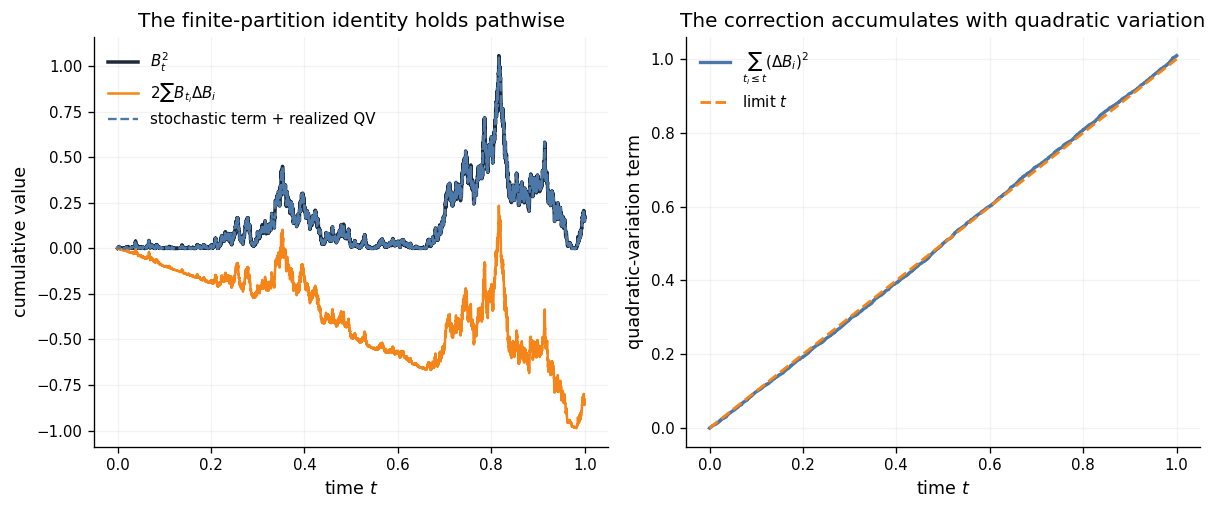

In [3]:
rng = np.random.default_rng(SEED + 21)
fine_count = 8_192
dt = T / fine_count
time = np.linspace(0.0, T, fine_count + 1)
dB = np.sqrt(dt) * rng.standard_normal(fine_count)
B = np.concatenate([[0.0], np.cumsum(dB)])
stochastic_term = np.concatenate([[0.0], 2.0 * np.cumsum(B[:-1] * dB)])
realized_qv = np.concatenate([[0.0], np.cumsum(dB**2)])
reconstruction = stochastic_term + realized_qv
identity_error = np.max(np.abs(reconstruction - B**2))

print(f"Maximum finite-grid identity error: {identity_error:.3e}")
print(f"Terminal realized QV: {realized_qv[-1]:.6f} (target {T:.6f})")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

axes[0].plot(time, B**2, color=INK, linewidth=2.1, label=r"$B_t^2$")
axes[0].plot(time, stochastic_term, color=ORANGE, linewidth=1.5, label=r"$2\sum B_{t_i}\Delta B_i$")
axes[0].plot(time, reconstruction, color=BLUE, linewidth=1.4, linestyle="--", label="stochastic term + realized QV")
axes[0].set_title("The finite-partition identity holds pathwise")
axes[0].set_xlabel(r"time $t$")
axes[0].set_ylabel("cumulative value")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(time, realized_qv, color=BLUE, linewidth=2.0, label=r"$\sum_{t_i\leq t}(\Delta B_i)^2$")
axes[1].plot(time, time, color=ORANGE, linestyle="--", linewidth=1.7, label=r"limit $t$")
axes[1].set_title("The correction accumulates with quadratic variation")
axes[1].set_xlabel(r"time $t$")
axes[1].set_ylabel("quadratic-variation term")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 2.</strong> The exact finite-grid decomposition of $B_t^2$ and cumulative realized quadratic variation along one Brownian path with $8{,}192$ intervals.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The stochastic sum alone does not reproduce the square. Adding realized quadratic variation restores the endpoint identity at every grid time, and that correction tracks calendar time on the fine partition. Its convergence to $t$ supplies the $dt$ term in the continuous formula.</p>

## 3. Time dependence can cancel the Itô drift

For $f\in C^1(\mathbb R_+,C^2(\mathbb R))$,

$$
df(t,B_t)
=\partial_xf(t,B_t)\,dB_t
+\left\{\partial_tf(t,B_t)+\frac12\partial_x^2f(t,B_t)\right\}dt.
$$

If $\partial_tf+\tfrac12\partial_x^2f=0$, the drift term vanishes and $f(t,B_t)$ is a local martingale. The course gives an additional square-integrability condition that makes it a true martingale on a finite horizon.

For $\theta\in\mathbb R$,

$$
M_t=\exp\left(\theta B_t-\frac12\theta^2t\right)
$$

satisfies $dM_t=\theta M_t\,dB_t$ and $E(M_t)=1$. The factor $-\theta^2t/2$ cancels the Itô correction generated by the exponential curvature.

Terminal sample mean: 1.007161
Terminal theoretical Monte Carlo SE: 0.006695
Largest standardized mean discrepancy away from t=0: 1.709


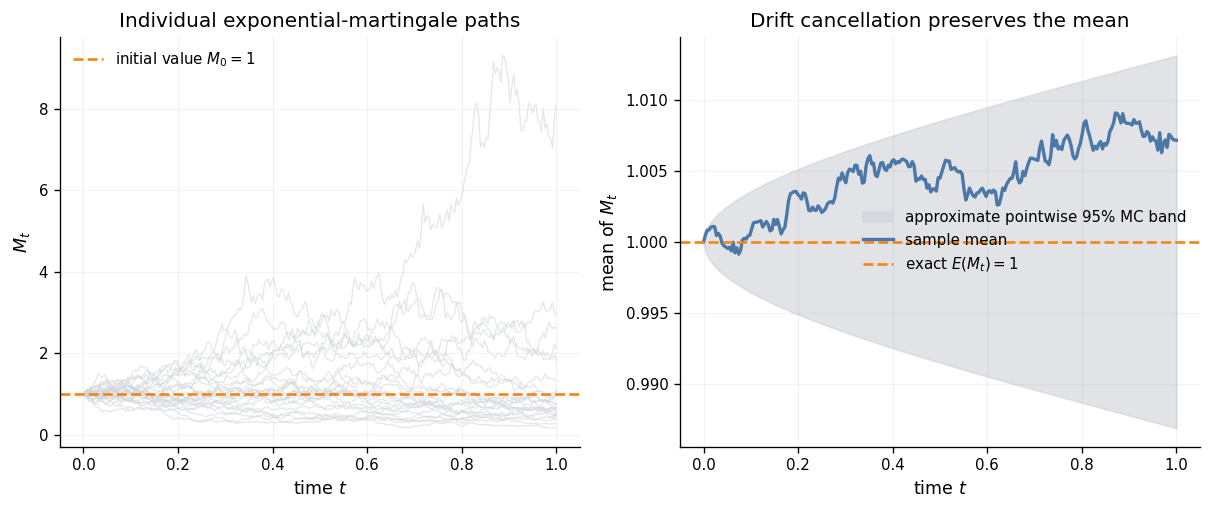

In [4]:
rng = np.random.default_rng(SEED + 22)
n_paths = 20_000
interval_count = 256
theta = 0.8
dB, B_paths = brownian_paths(rng, n_paths, interval_count, T)
time = np.linspace(0.0, T, interval_count + 1)
M = np.exp(theta * B_paths - 0.5 * theta**2 * time)
sample_mean = M.mean(axis=0)
exact_se = np.sqrt((np.exp(theta**2 * time) - 1.0) / n_paths)
maximum_standardized_error = np.max(np.abs(sample_mean - 1.0) / np.maximum(exact_se, 1e-12))

print(f"Terminal sample mean: {sample_mean[-1]:.6f}")
print(f"Terminal theoretical Monte Carlo SE: {exact_se[-1]:.6f}")
print(f"Largest standardized mean discrepancy away from t=0: {np.max(np.abs(sample_mean[1:] - 1.0) / exact_se[1:]):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

for row in range(24):
    axes[0].plot(time, M[row], color=LIGHT_GREY, linewidth=0.8, alpha=0.55)
axes[0].axhline(1.0, color=ORANGE, linestyle="--", linewidth=1.6, label=r"initial value $M_0=1$")
axes[0].set_title("Individual exponential-martingale paths")
axes[0].set_xlabel(r"time $t$")
axes[0].set_ylabel(r"$M_t$")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].fill_between(time, 1.0 - 1.96 * exact_se, 1.0 + 1.96 * exact_se, color=LIGHT_GREY, alpha=0.65, label="approximate pointwise 95% MC band")
axes[1].plot(time, sample_mean, color=BLUE, linewidth=2.0, label="sample mean")
axes[1].axhline(1.0, color=ORANGE, linestyle="--", linewidth=1.6, label=r"exact $E(M_t)=1$")
axes[1].set_title("Drift cancellation preserves the mean")
axes[1].set_xlabel(r"time $t$")
axes[1].set_ylabel(r"mean of $M_t$")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 3.</strong> Sample paths and the Monte Carlo mean of $M_t=\exp(0.8B_t-0.32t)$ from $20{,}000$ paths; the approximate pointwise $95\%$ band uses the exact variance of $M_t$ and a normal approximation for the sample mean.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Individual positive paths spread out as time increases, yet their sample mean remains near one within Monte Carlo uncertainty. Itô's formula and the verified integrability condition establish the martingale property; the ensemble plot reports its finite-sample consequence.</p>

## 4. A standard process carries drift and local variance into the chain rule

In the course notation, a standard process satisfies

$$
dX_t=a_t\,dt+b_t\,dB_t,
$$

with pathwise integrability of $a$ and local square integrability of $b$. For $f\in C^1(\mathbb R_+,C^2(\mathbb R))$, Theorem 5.12 gives

$$
df(t,X_t)
=\left(\partial_tf+a_t\partial_xf+\frac12b_t^2\partial_x^2f\right)(t,X_t)dt
+b_t\partial_xf(t,X_t)\,dB_t.
$$

For $X_t=x_0+\mu t+\sigma B_t$ and $f(x)=x^2$,

$$
X_t^2-X_0^2
=2\sigma\int_0^tX_s\,dB_s
+\int_0^t(2\mu X_s+\sigma^2)\,ds.
$$

The term $\sigma^2dt$ is the curvature correction generated by the local variance $b_t^2=\sigma^2$.

Sup-norm discretization discrepancy: 0.011105
Terminal transformed change: +0.144776
Terminal reconstructed change: +0.149029


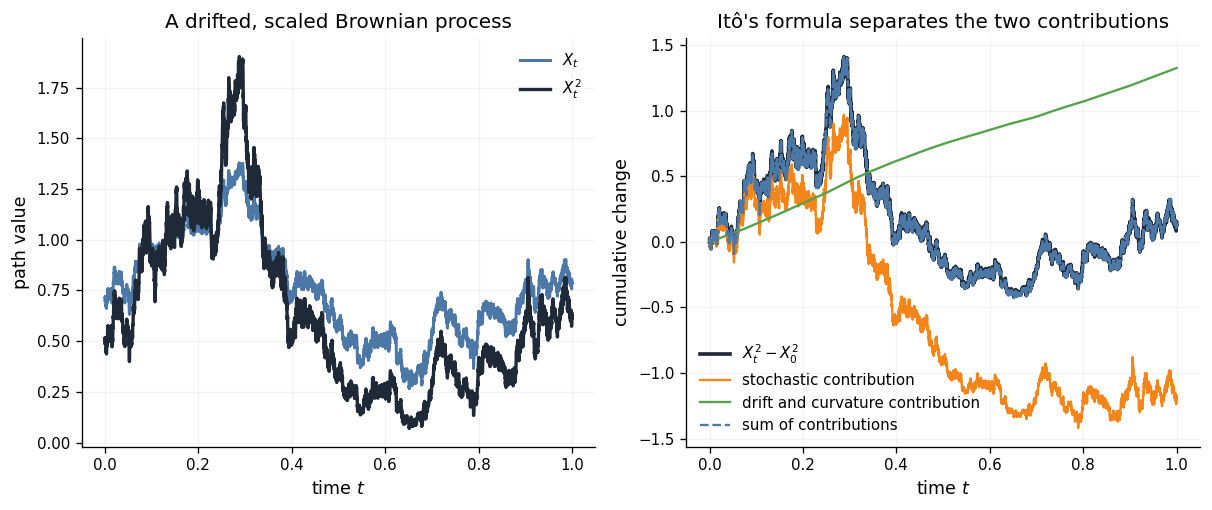

In [5]:
rng = np.random.default_rng(SEED + 23)
fine_count = 8_192
dt = T / fine_count
time = np.linspace(0.0, T, fine_count + 1)
dB = np.sqrt(dt) * rng.standard_normal(fine_count)
B = np.concatenate([[0.0], np.cumsum(dB)])
x0 = 0.7
mu = 0.45
sigma = 0.8
X_process = x0 + mu * time + sigma * B

stochastic_part = np.concatenate([[0.0], np.cumsum(2.0 * sigma * X_process[:-1] * dB)])
drift_part = np.concatenate([[0.0], np.cumsum((2.0 * mu * X_process[:-1] + sigma**2) * dt)])
transformed_change = X_process**2 - x0**2
reconstructed = stochastic_part + drift_part
sup_error = np.max(np.abs(transformed_change - reconstructed))

print(f"Sup-norm discretization discrepancy: {sup_error:.6f}")
print(f"Terminal transformed change: {transformed_change[-1]:+.6f}")
print(f"Terminal reconstructed change: {reconstructed[-1]:+.6f}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

axes[0].plot(time, X_process, color=BLUE, linewidth=1.8, label=r"$X_t$")
axes[0].plot(time, X_process**2, color=INK, linewidth=2.0, label=r"$X_t^2$")
axes[0].set_title("A drifted, scaled Brownian process")
axes[0].set_xlabel(r"time $t$")
axes[0].set_ylabel("path value")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(time, transformed_change, color=INK, linewidth=2.2, label=r"$X_t^2-X_0^2$")
axes[1].plot(time, stochastic_part, color=ORANGE, linewidth=1.4, label="stochastic contribution")
axes[1].plot(time, drift_part, color=GREEN, linewidth=1.4, label="drift and curvature contribution")
axes[1].plot(time, reconstructed, color=BLUE, linewidth=1.4, linestyle="--", label="sum of contributions")
axes[1].set_title("Itô's formula separates the two contributions")
axes[1].set_xlabel(r"time $t$")
axes[1].set_ylabel("cumulative change")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 4.</strong> The square of $X_t=0.7+0.45t+0.8B_t$ and its stochastic and finite-variation contributions on a fine grid.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The stochastic integral produces the irregular component of the transformed path. The smoother contribution combines ordinary drift with the $\sigma^2dt$ curvature correction. Their sum tracks $X_t^2-X_0^2$, with the remaining gap coming from time discretisation.</p>

## 5. Applying the formula to $\log S_t$ reveals the GBM drift shift

Let geometric Brownian motion satisfy

$$
dS_t=\mu S_t\,dt+\sigma S_t\,dB_t,
\qquad S_0>0.
$$

For $f(s)=\log s$, $f'(s)=1/s$ and $f''(s)=-1/s^2$. Itô's formula gives

$$
d\log S_t
=\left(\mu-\frac12\sigma^2\right)dt+\sigma\,dB_t,
$$

and hence

$$
S_t=S_0\exp\left\{\left(\mu-\frac12\sigma^2\right)t+\sigma B_t\right\}.
$$

The mean level still satisfies $E(S_t)=S_0e^{\mu t}$, while the mean log level grows at the smaller rate $\mu-\sigma^2/2$. These are different quantities because exponentiation is nonlinear.

Naive drift mu: 0.180000
Log drift mu - sigma^2/2: 0.028750
Terminal sample mean log S: +0.027183
Terminal theoretical mean log S: +0.028750


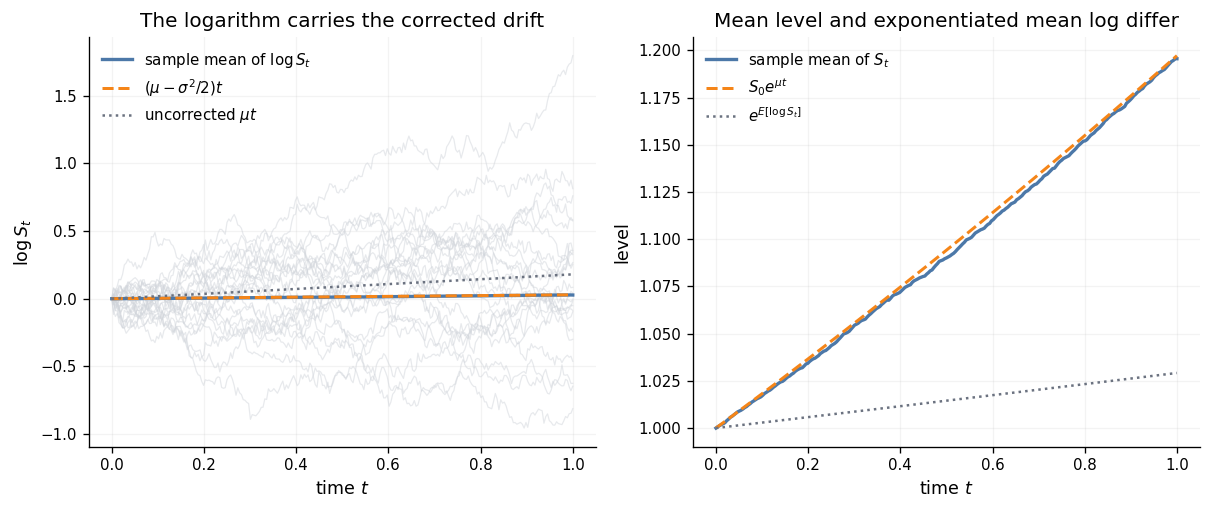

In [6]:
rng = np.random.default_rng(SEED + 24)
n_paths = 18_000
interval_count = 256
S0 = 1.0
mu = 0.18
sigma = 0.55
dB, B_paths = brownian_paths(rng, n_paths, interval_count, T)
time = np.linspace(0.0, T, interval_count + 1)
log_S = np.log(S0) + (mu - 0.5 * sigma**2) * time + sigma * B_paths
S = np.exp(log_S)
mean_log = log_S.mean(axis=0)
mean_level = S.mean(axis=0)
theoretical_mean_log = np.log(S0) + (mu - 0.5 * sigma**2) * time
theoretical_mean_level = S0 * np.exp(mu * time)

print(f"Naive drift mu: {mu:.6f}")
print(f"Log drift mu - sigma^2/2: {mu - 0.5 * sigma**2:.6f}")
print(f"Terminal sample mean log S: {mean_log[-1]:+.6f}")
print(f"Terminal theoretical mean log S: {theoretical_mean_log[-1]:+.6f}")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.35))

for row in range(24):
    axes[0].plot(time, log_S[row], color=LIGHT_GREY, linewidth=0.75, alpha=0.5)
axes[0].plot(time, mean_log, color=BLUE, linewidth=2.0, label=r"sample mean of $\log S_t$")
axes[0].plot(time, theoretical_mean_log, color=ORANGE, linestyle="--", linewidth=1.8, label=r"$(\mu-\sigma^2/2)t$")
axes[0].plot(time, np.log(S0) + mu * time, color=GREY, linestyle=":", linewidth=1.5, label=r"uncorrected $\mu t$")
axes[0].set_title("The logarithm carries the corrected drift")
axes[0].set_xlabel(r"time $t$")
axes[0].set_ylabel(r"$\log S_t$")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.14)

axes[1].plot(time, mean_level, color=BLUE, linewidth=2.0, label=r"sample mean of $S_t$")
axes[1].plot(time, theoretical_mean_level, color=ORANGE, linestyle="--", linewidth=1.8, label=r"$S_0e^{\mu t}$")
axes[1].plot(time, np.exp(theoretical_mean_log), color=GREY, linestyle=":", linewidth=1.5, label=r"$e^{E[\log S_t]}$")
axes[1].set_title("Mean level and exponentiated mean log differ")
axes[1].set_xlabel(r"time $t$")
axes[1].set_ylabel(r"level")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)

plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 5.</strong> Log paths, empirical mean log level, and empirical mean level for geometric Brownian motion with $\mu=0.18$ and $\sigma=0.55$, using $18{,}000$ paths.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The mean log path follows the Itô-corrected slope $\mu-\sigma^2/2$, whereas the mean level follows $S_0e^{\mu t}$. The dotted curve $e^{E[\log S_t]}$ lies below $E(S_t)$, showing why the log drift correction and the level drift can coexist without contradiction.</p>

## References

- *MATH3015: Stochastic Processes*, Chapter 5, Theorem 5.1, Theorem 5.4, Remark 5.5, Example 5.6, and Theorem 5.12.
- Fima C. Klebaner, *Introduction to Stochastic Calculus with Applications*, 3rd ed., Chapter 4, Sections 4.4-4.6 and Theorem 4.18.